# Дамашняя работа №2

Дадзеныя: Titanic з OpenML

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

import pandas as pd
import seaborn as sns

# Імпарт модуляў
import custom_imputer as ci
import data_loader as dl
import visualizer as vis

from visualizer import ChartConfig, plot_scatter_clean

In [2]:
import seaborn as sns
import visualizer as vis

# Крок 1: Загрузка дадзеных

In [3]:
print("Загрузка даДзеных з OpenML...")
#X, y = dl.load_from_openml(name_or_id="titanic", target_column="survived")
dfmodel = dl.load_from_openml(name_or_id="titanic")

target_column='survived'
X = dfmodel.drop(columns=[target_column])
y = dfmodel[target_column]

Загрузка даДзеных з OpenML...


In [4]:
X.head(3)

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [5]:
y.head(3)

0    1
1    1
2    0
Name: survived, dtype: category
Categories (2, str): ['0', '1']

In [ ]:
# Спрашчаем мэтавы слупок для класіфікацыі (выдаляем пропускі, прыводзім да int)
# y = y.fillna(0).astype(int) # у VSc не сварыўся чамусьці
y = y.astype(object).fillna(0).astype(int)
y.head(3)

0    1
1    1
2    0
Name: survived, dtype: int64

# Крок 2: Першасны аналіз дадзеных  
2.1 аналіз пропускаў, вывад статыстыкі
2.2 знаёмства з дадзенымі для выбара прыкмет для мадэлі лагістычнай рэгрэсіі

In [ ]:
# Крок 2.1: Першасны аналіз пропускаў
#ci.analyze_missing_data(X)


--- Аналіз пропускаў у даных ---
           Total          %
age          263  20.091673
fare           1   0.076394
cabin       1014  77.463713
embarked       2   0.152788
boat         823  62.872422
body        1188  90.756303
home.dest    564  43.086325
--------------------------------


,Total,%
pclass,0,0.000000
name,0,0.000000
sex,0,0.000000
age,263,20.091673
sibsp,0,0.000000
parch,0,0.000000
ticket,0,0.000000
fare,1,0.076394
cabin,1014,77.463713
embarked,2,0.152788


In [23]:
analisis = ci.analyze_missing_data(X)
ci.print_missing_report(X, analisis) #Генеруе падрабязную справаздачу аб пропушчаных значэннях.

--- Аналіз пропускаў у даных ---
           Total          %
age          263  20.091673
fare           1   0.076394
cabin       1014  77.463713
embarked       2   0.152788
boat         823  62.872422
body        1188  90.756303
home.dest    564  43.086325
--------------------------------
--- АНАЛІЗ ПРОПУСКАЎ У СЛУПКАХ ---
           Total          %
age          263  20.091673
fare           1   0.076394
cabin       1014  77.463713
embarked       2   0.152788
boat         823  62.872422
body        1188  90.756303
home.dest    564  43.086325
----------------------------------
Агульная колькасць ячэек: 17017
Агульная колькасць пропускаў: 3855 (22.65%)
----------------------------------


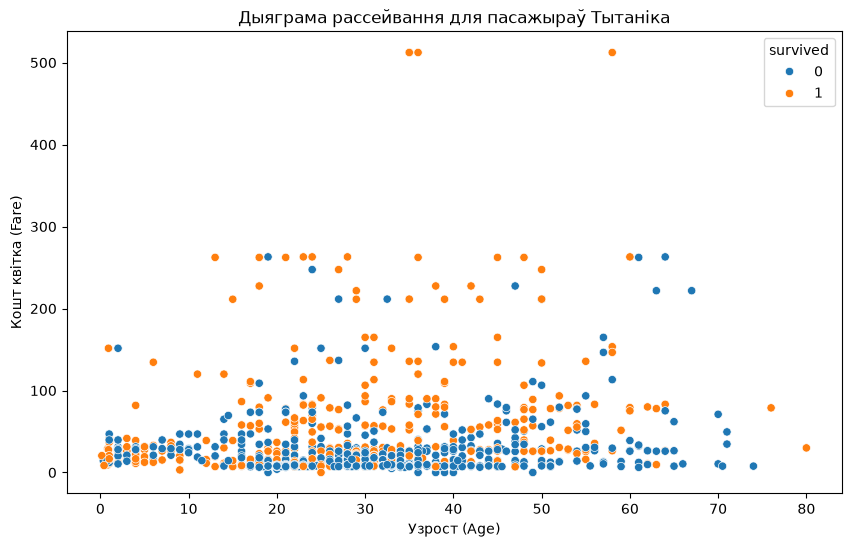

In [24]:
# Дыяграма рассейвання уплыў узрост\кошт квітка - на выжывальнасць
# Структуруем усе подпісы і дадзеныя ў адным месцы
titanic_chart = ChartConfig(
    df=dfmodel,
    x_col='age',
    y_col='fare',
    hue_col='survived',
    title='Дыяграма рассейвання для пасажыраў Тытаніка',
    x_label='Узрост (Age)',
    y_label='Кошт квітка (Fare)'
)

plot_scatter_clean(titanic_chart)

In [ ]:
# Адбор прыкмет па якіх будзем праводзіць класіфікацыю
features_cat_freq = ['embarked']    # Катэгорыі, дзе мала пропускаў (заменім модай)
features_cat_CONST = ['sex']        # Катэгорыі, дзе шмат пропускаў (заменім на 'Unknown')
features_num = ['age', 'fare', 'pclass'] # Лічбавыя слупкі (заменім медыянай)

# Крок 3: Папярэдняя апрацоўка дадзеных

In [29]:
print("Запаўненне пропускаў і падрыхтоўка дадзеных...")

# 1. Выклікаем функцыю preprocess_pipeline і распакоўваем картэж

# custom_reg_col="age" # не дапрацаваная стратэгія запаўнення узросту праз лінейную рэгрэсію
# reg_predictors=["pclass", "sex", "fare"]
X_numpy, my_preprocessor = ci.preprocess_pipeline(X, numeric_features=features_num, categorical_const_features=features_cat_freq, categorical_freq_features=features_cat_CONST)

Запаўненне пропускаў і падрыхтоўка дадзеных...
Пропускі запоўненыя, лічбы адмаштабаваныя, катэгорыі закадаваныя!


In [30]:
my_preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat_f', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

In [31]:
import pandas as pd

# 2. Ператвараем масіў NumPy назад у табліцу Pandas DataFrame
X_cleaned = pd.DataFrame(
    X_numpy,
    columns=my_preprocessor.get_feature_names_out(),
    index=X.index  # захоўваем арыгінальныя індэксы радкоў
)

# 3. правяраем як яно там
X_cleaned.head(3)


,num__age,num__fare,num__pclass,cat_f__sex_male,cat_с__embarked_Q,cat_с__embarked_S,cat_с__embarked_Unknown
0,-0.039005,3.442584,-1.546098,0.0,0.0,1.0,0.0
1,-2.215952,2.286639,-1.546098,1.0,0.0,1.0,0.0
2,-2.131977,2.286639,-1.546098,0.0,0.0,1.0,0.0


# Крок 4: Падзел на навучальную і тэставую выбаркі

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned, y, test_size=0.2, random_state=42, stratify=y
)

# Крок 5: Стварэнне і навучанне мадэлі лагістычнай рэгрэсіі

In [33]:
print("Навучанне мадэлі Logistic Regression...")
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

Навучанне мадэлі Logistic Regression...


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

# Крок 6: Тэкставая выснова метрык якасці

In [34]:
y_pred = model.predict(X_test)
print("\nФiнальная статыстыка класіфікацыі:")
print(classification_report(y_test, y_pred))


Фiнальная статыстыка класіфікацыі:
              precision    recall  f1-score   support

           0       0.84      0.85      0.84       162
           1       0.75      0.74      0.74       100

    accuracy                           0.81       262
   macro avg       0.79      0.79      0.79       262
weighted avg       0.80      0.81      0.81       262



# Крок 7: Візуалізацыя
Матрыца памылак  
Roc-крывая
Гістаграмма вагі каэффіцыентаў мадэлі
прадказаныя і зыходныя мэтавыя дадзеныя

Генерацыя графікаў з модуля 'visualizer'...


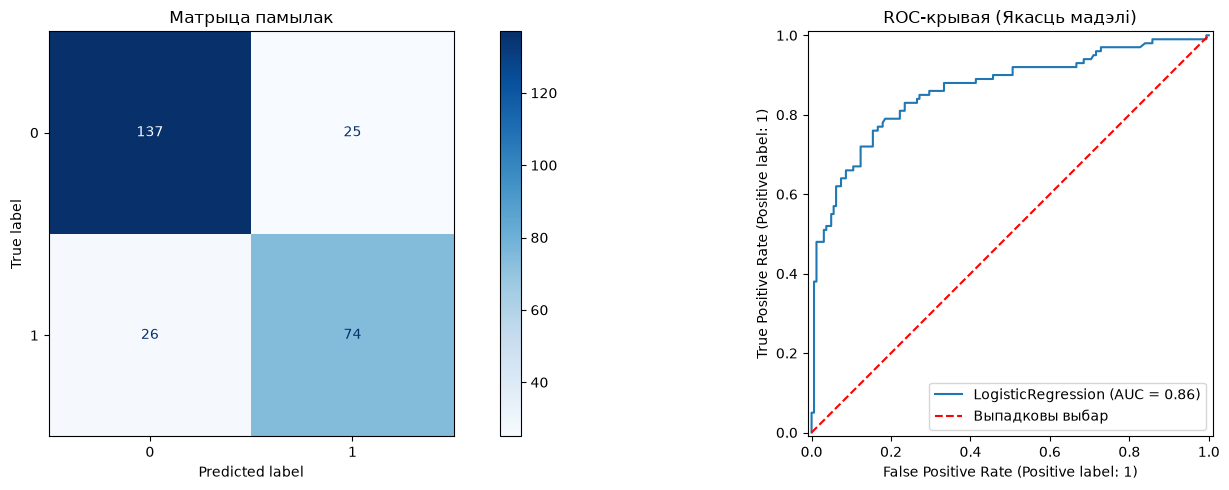

In [35]:
print("Генерацыя графікаў з модуля 'visualizer'...")

vis.plot_classification_results(model, X_test, y_test, X_train.columns,type_vis_method = 1)

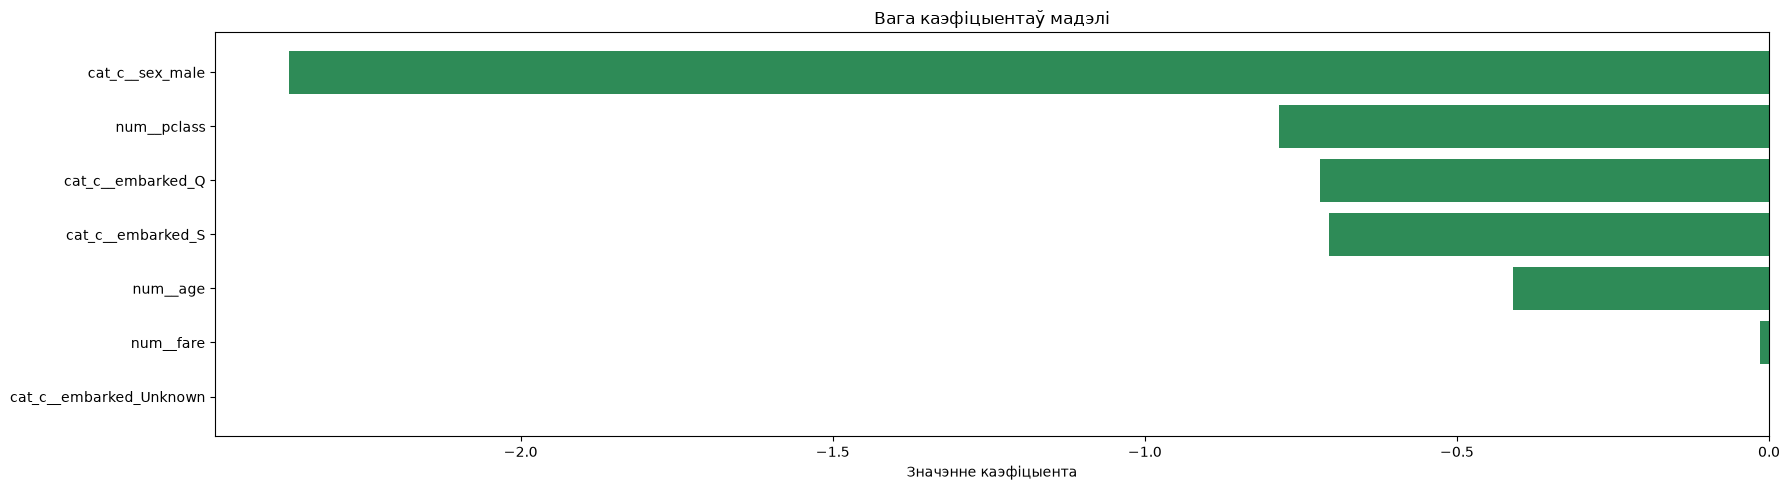

In [18]:
vis.plot_classification_results(model, X_test, y_test, X_train.columns, type_vis_method = 2)

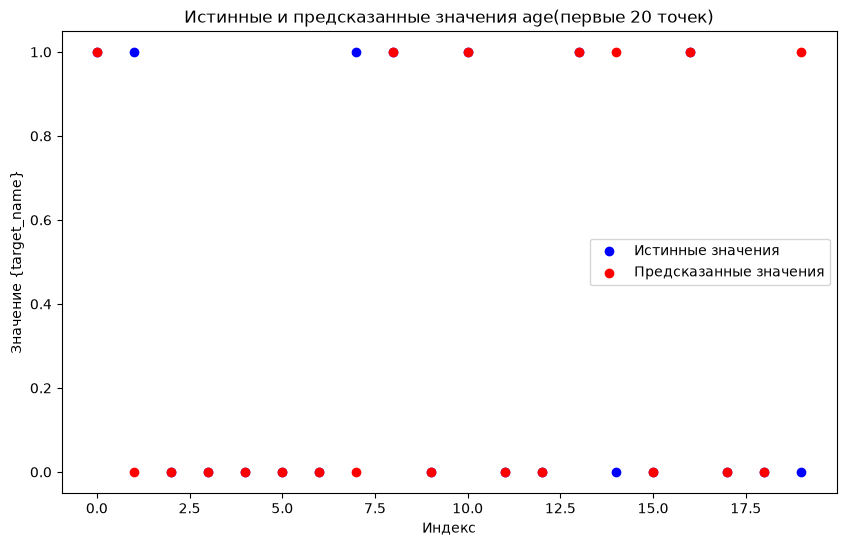

In [20]:
vis.plot_predictions(
    y_test, 
    y_pred, 
    num_points=20, 
    target_name='age', 
    type_vis_method=1
    )

In [ ]:
#vis.plot_predictions(y_test, y_pred, num_points=10, type_vis_method=2)

In [ ]:
# Пабудова парных графикаў з дапамогай sns
# vis.plot_cl_results(X_test, y_test, X_train.columns, target_column)